REVENUE DRIVER ANALYSIS USING COFFEE SHOP DATASET

#Business Understanding
The Coffee Shop Dataset contains several variables, including: number of customers, average order value, operating hours per day, number of employees, marketing spend per day, location foot traffic, and daily revenue.

In [15]:
#Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
from datetime import timedelta
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error  

In [17]:
#Load Dataset
CS = pd.read_csv("D://0.#Start Journey/0. Portfolio/1. Coffee Shop Analysis/coffee_shop_revenue.csv")
CS.head()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
0,152,6.74,14,4,106.62,97,1547.81
1,485,4.50,12,8,57.83,744,2084.68
2,398,9.09,6,6,91.76,636,3118.39
3,320,8.48,17,4,462.63,770,2912.20
4,156,7.44,17,2,412.52,232,1663.42


In [18]:
#Exploratory Data Analysis
CS.info()
CS.describe()
CS.isnull().sum()
CS.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Number_of_Customers_Per_Day  2000 non-null   int64  
 1   Average_Order_Value          2000 non-null   float64
 2   Operating_Hours_Per_Day      2000 non-null   int64  
 3   Number_of_Employees          2000 non-null   int64  
 4   Marketing_Spend_Per_Day      2000 non-null   float64
 5   Location_Foot_Traffic        2000 non-null   int64  
 6   Daily_Revenue                2000 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 109.5 KB


0

<Axes: >

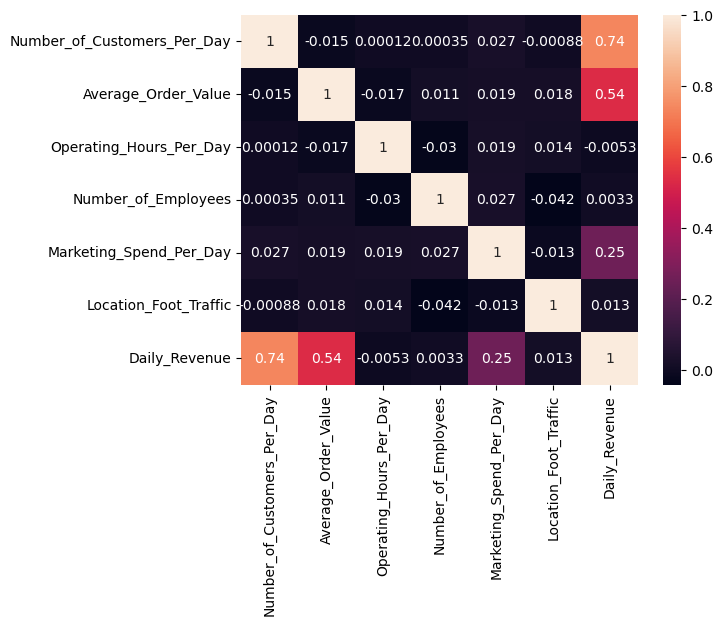

In [19]:
import seaborn as sns
sns.heatmap(CS.corr(), annot=True)

#Insight Heatmap

1. The value of 0.74 for the number of cust per day indicates that the more customer the coffee shop has, the more significantly the revenue increases. This is logical because revenue is closely related to the number of customers and the average order value.
2. The value of 0.54 for average order value shows that higher spending per customer contributes to an increase in revenue.
3. Marketing spend also has an influence on revenue, but it's not the dominant factor since its value is relatively low at 0.25.

In [20]:
#Feature & Target Split
X = CS.drop('Daily_Revenue', axis=1)
y = CS['Daily_Revenue']
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
#Model Training
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [22]:
gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)

In [23]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [24]:
#Model Evaluation
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')
print(f'Mean Absolute Error: {mae}')
print(f'MAPE: {mape * 100: .2f}%')

Mean Squared Error: 47501.55401971976
R^2 Score: 0.9491618691981997
Mean Absolute Error: 175.3933364999999
MAPE:  13.55%


Random Forest 94.91%

- R Square= 0.94 (94.91%), which indicates an excellent model performance.
- MAE = approximately ± $175, meaning the prediction error is relatively small compared to the scale of the data.
- MAPE = 13%, which is still considered acceptable for this analysis.

In [25]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance)

                       feature  importance
0  Number_of_Customers_Per_Day    0.569201
1          Average_Order_Value    0.361881
4      Marketing_Spend_Per_Day    0.050524
5        Location_Foot_Traffic    0.007496
2      Operating_Hours_Per_Day    0.005593
3          Number_of_Employees    0.005304


#BUSINESS INSIGHT
- More than half of the revenue variation is driven by the number of customers.
- Average order value also has a strong influence on revenue, which means that upselling and pricing strategies play an important role in increasing sales.
- Marketing spend does not have a highly significant direct impact on revenue.

In [26]:
import shap
shap.initjs()

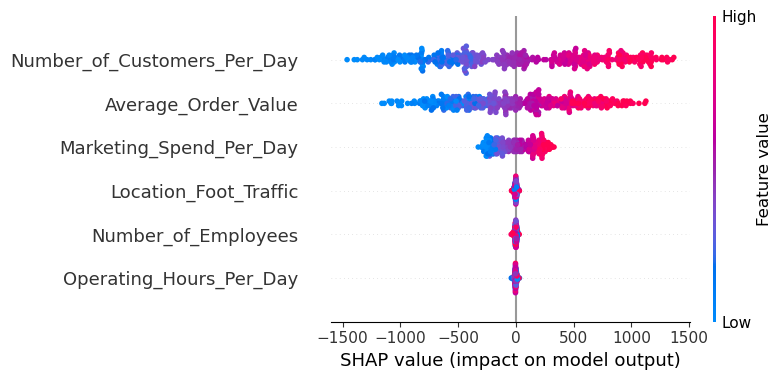

In [27]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test.values)

The number of customers affects revenue. The more customers the coffee shop has, the higher the revenue will be.

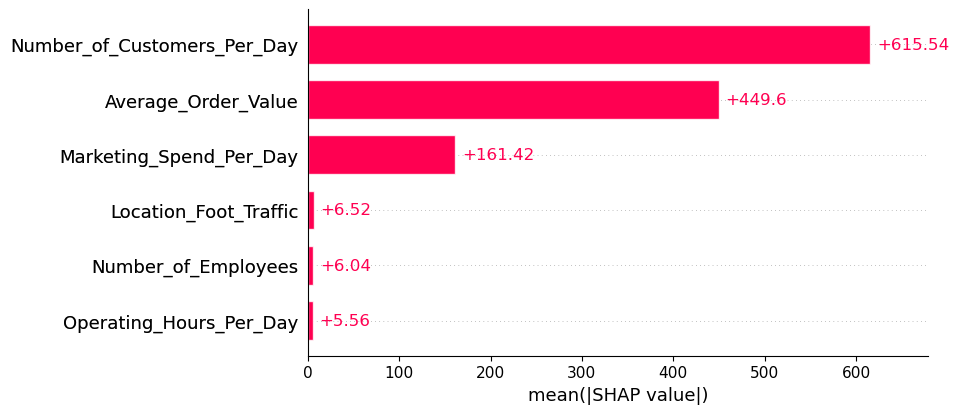

In [36]:
shap.plots.bar(shap_values)

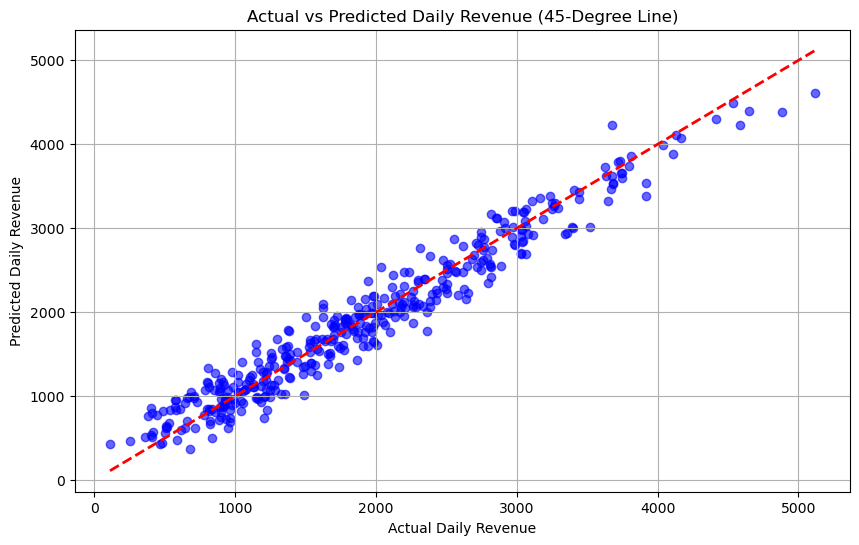

In [35]:
# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Daily Revenue')
plt.ylabel('Predicted Daily Revenue')
plt.title('Actual vs Predicted Daily Revenue (45-Degree Line)')
plt.grid(True)
plt.show()

Overall, the model is able to capture the relationship patterns between the features and revenue effectively.